# scPoli校正流程 Python版

把`原始基因表达h5ad`和`cell×10 scPoli h5ad`合并，按Seurat代码逻辑做epithelial subset、Normalize、UMAP过滤、scPoli聚类、local purity过滤、marker DotPlot和统计输出。

该文件的输出都在：/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_allhuman/work_0513_2

# import

In [1]:
import anndata
import os
import numpy as np
import pandas as pd
import scanpy as sc
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
sc.settings.verbosity=2
sc.settings.seed=1234
np.random.seed(1234)

In [ ]:
raw_h5ad="../../7_mapping_new_data/0511_rename_noIAISR/output_human/Atlas_allhuman_with_measure_allgeneID-inner-counts-annot.h5ad"##所有人类数据 原始counts + annot,现在这个文件中的cell_type_level1是ground truth
scpoli_h5ad="../../7_mapping_new_data/0507_no_IAISR/output_human/level1_human_atlas_nogene_noIAISR_2.h5ad"### all human scpoli data without gene names, but with annotation
outdir="./output_allhuman/work_0513_2/"
counts_layer="rounded_corrected_counts"
original_celltype_col="cell_type_level1"##原始文件里的标签
os.makedirs(outdir,exist_ok=True)

In [ ]:
#####读取文件 按 adata_scpoli 的细胞ID 对齐 adata_raw
adata_raw=sc.read_h5ad(raw_h5ad)
adata_scpoli=sc.read_h5ad(scpoli_h5ad)
print(adata_raw)
print(adata_raw.obs_names)
print(adata_scpoli)
print(adata_scpoli.obs_names)

In [ ]:
###得到共同的细胞
adata_raw.obs_names=adata_raw.obs_names.astype(str)
adata_scpoli.obs_names=adata_scpoli.obs_names.astype(str)
##保留原始barcode
adata_raw.obs["barcode_for_match"]=adata_raw.obs_names
adata_scpoli.obs["barcode_for_match"]=adata_scpoli.obs_names.str[:-2]
##用 sample + barcode 构建唯一ID
adata_raw.obs["match_id"]=adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
adata_scpoli.obs["match_id"]=adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
##如果sample仍不唯一，就改成 dataset + sample + barcode
if adata_raw.obs["match_id"].duplicated().sum()>0 or adata_scpoli.obs["match_id"].duplicated().sum()>0:
    adata_raw.obs["match_id"]=adata_raw.obs["dataset"].astype(str)+"__"+adata_raw.obs["sample"].astype(str)+"__"+adata_raw.obs["barcode_for_match"].astype(str)
    adata_scpoli.obs["match_id"]=adata_scpoli.obs["dataset"].astype(str)+"__"+adata_scpoli.obs["sample"].astype(str)+"__"+adata_scpoli.obs["barcode_for_match"].astype(str)
print("raw duplicated match_id:",adata_raw.obs["match_id"].duplicated().sum())
print("scpoli duplicated match_id:",adata_scpoli.obs["match_id"].duplicated().sum())
if adata_raw.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_raw match_id仍有重复，不能安全匹配")
if adata_scpoli.obs["match_id"].duplicated().sum()>0:
    raise ValueError("adata_scpoli match_id仍有重复，不能安全匹配")
adata_raw.obs_names=adata_raw.obs["match_id"].astype(str)
adata_scpoli.obs_names=adata_scpoli.obs["match_id"].astype(str)

##空值填充为query
if "atlas_key" not in adata_scpoli.obs:
    adata_scpoli.obs["atlas_key"]="query"
else:
    adata_scpoli.obs["atlas_key"]=adata_scpoli.obs["atlas_key"].astype("object")
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].isna(),"atlas_key"]="query"
    adata_scpoli.obs.loc[adata_scpoli.obs["atlas_key"].astype(str).isin(["","nan","None","NA"]),"atlas_key"]="query"

print(adata_scpoli.obs["atlas_key"].value_counts(dropna=False))
##以 scpoli 为准，从 raw 中取相同细胞
scp_ids=adata_scpoli.obs_names
missing=scp_ids[~scp_ids.isin(adata_raw.obs_names)]
print("scpoli cells:",len(scp_ids))
print("missing in raw:",len(missing))
if len(missing)>0:
    print(missing[:50].tolist())
    raise ValueError("有 scpoli 细胞在 raw 中找不到")
adata=adata_raw[scp_ids,:].copy()
adata_com_scpoli=adata_scpoli.copy()
assert np.all(adata.obs_names==adata_com_scpoli.obs_names)
print("aligned adata:",adata)
print("aligned adata_com_scpoli:",adata_com_scpoli)

In [ ]:
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs['cell_type_level1'].value_counts()

In [ ]:
adata_query = adata[adata.obs['atlas_key'] == 'ref']
adata_query.obs['cell_type_level1'].value_counts()

In [ ]:
adata.obs['atlas_key'].value_counts()

In [ ]:
adata_com_scpoli.write("./output_allhuman/allhuman_scpoli_com.h5ad")
adata.write("./output_allhuman/allhuman_raw_com.h5ad")

In [ ]:
adata_com_scpoli

In [ ]:
adata

In [ ]:
##选择原始 counts 矩阵，并检查它像不像真正的原始计数
if counts_layer in adata.layers:
    adata.X=adata.layers[counts_layer].copy()
    print("use layer:",counts_layer)
else:
    print("layer not found,use adata.X:",counts_layer)
adata.layers["counts"]=adata.X.copy()
x=adata.layers["counts"]
v=x.data if sp.issparse(x) else np.ravel(x)
v=v[:min(len(v),1000000)]
print("counts min",np.min(v),"max",np.max(v),"integer-like",np.allclose(v,np.round(v)))

In [ ]:
#####添加需要的obs
run_tag="precorrect"
for c in ["leiden","cell_type_pred","cell_type_uncert","query","cell_type_pred_ref","cell_type_level1_human","atlas_key"]:
    if c in adata_com_scpoli.obs:
        adata.obs[c]=adata_com_scpoli.obs[c].values
        print("+obs",c)
X=adata_com_scpoli.X.toarray() if sp.issparse(adata_com_scpoli.X) else np.asarray(adata_com_scpoli.X)
adata.obsm["X_scPoli"]=X
if "X_umap" in adata_com_scpoli.obsm:
    adata.obsm["X_umap"]=np.asarray(adata_com_scpoli.obsm["X_umap"])
print("X_scPoli",adata.obsm["X_scPoli"].shape)
print("X_umap",adata.obsm["X_umap"].shape if "X_umap" in adata.obsm else None)
adata.write(os.path.join(outdir,f"allhuman_raw_counts_scpoli_{run_tag}.h5ad"))

In [ ]:
##合并后先画一张全体细胞的 UMAP，检查 cell_type_pred 是否正常
if "X_umap" in adata.obsm and "cell_type_pred" in adata.obs:
    sc.pl.umap(adata,color="cell_type_pred",legend_loc="on data",frameon=False,size=1,show=False)
    plt.savefig(os.path.join(outdir,"umap_cell_type_pred_full.pdf"),bbox_inches="tight")
    plt.close()
adata

In [ ]:
adata_query = adata[adata.obs['atlas_key']=='query']
adata_query.obs['cell_type_level1'].value_counts()

In [ ]:
adata_query.obs['cell_type_pred'].value_counts()

# mac/mono/neu

In [8]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/mac_mono_neu/"

In [ ]:
adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

In [ ]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [ ]:
mac_mono_neu = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Macrophage", "Monocyte", "Neutrophil"],
    outdir=outdir,
    prefix="mac_mono_neu",
    cluster_key="leiden_scpoli_res3"
)

In [10]:
work = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 86301 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [17]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    # "Neutrophil_2": ["FCGR3B", "CSF3R", "CXCR2", "S100A8", "S100A9", "LCN2", "MMP8", "MMP9", "ELANE", "MPO", "CEACAM8"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [18]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "mac_mono_neu_cluster_correction_summary.csv"))

         major_pred  major_pred_frac    major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                             
0        Neutrophil         1.000000      Neutrophil           0.999185     3682          Neutrophil
1          Monocyte         1.000000        Monocyte           0.973130     3089            Monocyte
2          Monocyte         0.997932        Monocyte           0.910376     2901            Monocyte
3          Monocyte         0.964161        Monocyte           0.992345     2874            Monocyte
4        Macrophage         1.000000      Macrophage           0.959560     2819          Macrophage
5        Macrophage         0.999640      Macrophage           0.846792     2774          Macrophage
6        Macrophage         1.000000      Macrophage           0.985040     2607          Macrophage
7        Macrophage         0.994896      Macrophage           0.683157     2547          M

In [20]:
corrected_annotation = {
    "0": "Neutrophil",
    "1": "Monocyte",
    "2": "Monocyte",
    "3": "Monocyte",
    "4": "Macrophage",
    "5": "Macrophage",
    "6": "Macrophage",
    "7": "Macrophage",
    "8": "Macrophage",
    "9": "Neutrophil",
    "10": "Macrophage",
    "11": "Neutrophil",
    "12": "Monocyte",
    "13": "Macrophage",
    "14": "Macrophage",
    "15": "Macrophage",
    "16": "Macrophage",
    "17": "Macrophage",
    "18": "Macrophage",
    "19": "Macrophage",
    "20": "Macrophage",
    "21": "Macrophage",
    "22": "Neutrophil",
    "23": "Macrophage",
    "24": "Macrophage",
    "25": "Monocyte",##inflammatory monocyte
    "26": "Macrophage",
    "27": "Monocyte",
    "28": "Macrophage",
    "29": "Macrophage",
    "30": "Monocyte",
    "31": "Macrophage",
    "32": "Macrophage",
    "33": "Macrophage",
    "34": "Macrophage",
    "35": "Macrophage",
    "36": "Neutrophil",
    "37": "Macrophage",
    "38": "Neutrophil",
    "39": "Macrophage",
    "40": "Macrophage",
    "41": "Neutrophil",
    "42": "Macrophage",
    "43": "Macrophage",
    "44": "Neutrophil"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Macrophage    55921
Monocyte      16642
Neutrophil    13738
Name: count, dtype: int64


In [22]:
work.write_h5ad(os.path.join(outdir, "mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))

In [ ]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_mac_mono_neu_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_mac_mono_neu_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# smc/fibro

In [24]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/smc_fibro"

In [ ]:
# adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
# adata

In [ ]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [ ]:
smc_fibro = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Smooth muscle cell", "Fibroblast"],
    outdir=outdir,
    prefix="smc_fibro",
    cluster_key="leiden_scpoli_res3"
)

In [26]:
work = sc.read_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 92250 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [27]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_smc_fibro_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [28]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "smc_fibro_cluster_correction_summary.csv"))

                 major_pred  major_pred_frac        major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                         
0        Smooth muscle cell         1.000000  Smooth muscle cell           0.935529     4281  Smooth muscle cell
1                Fibroblast         1.000000          Fibroblast           0.999749     3991          Fibroblast
2        Smooth muscle cell         0.993863  Smooth muscle cell           0.601953     3585  Smooth muscle cell
3                Fibroblast         1.000000          Fibroblast           0.988640     3521          Fibroblast
4                Fibroblast         0.835270          Fibroblast           0.379140     3442           Uncertain
5        Smooth muscle cell         1.000000  Smooth muscle cell           0.965711     3383  Smooth muscle cell
6        Smooth muscle cell         1.000000  Smooth muscle cell           0.756674     3259  Sm

In [29]:
corrected_annotation = {
    "0": "Smooth muscle cell",
    "1": "Fibroblast",
    "2": "Smooth muscle cell",
    "3": "Fibroblast",
    "4": "Erythrocyte/Erythroid",
    "5": "Smooth muscle cell",
    "6": "Smooth muscle cell",
    "7": "Fibroblast",
    "8": "Smooth muscle cell",
    "9": "Fibroblast",
    "10": "Smooth muscle cell",
    "11": "Fibroblast",
    "12": "Fibroblast",
    "13": "Smooth muscle cell",
    "14": "Smooth muscle cell",
    "15": "Fibroblast",
    "16": "Smooth muscle cell",
    "17": "Fibroblast",
    "18": "Smooth muscle cell",
    "19": "Fibroblast",
    "20": "Smooth muscle cell",
    "21": "Fibroblast",
    "22": "Fibroblast",
    "23": "Fibroblast",
    "24": "Fibroblast",
    "25": "Fibroblast",
    "26": "Fibroblast",
    "27": "Smooth muscle cell",
    "28": "Fibroblast",
    "29": "Fibroblast",
    "30": "Fibroblast",
    "31": "Smooth muscle cell",
    "32": "Fibroblast",
    "33": "Fibroblast",
    "34": "Smooth muscle cell",
    "35": "Smooth muscle cell",
    "36": "Fibroblast",
    "37": "Fibroblast",
    "38": "Smooth muscle cell",
    "39": "Smooth muscle cell",
    "40": "Smooth muscle cell",
    "41": "Fibroblast"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Fibroblast               48012
Smooth muscle cell       40796
Erythrocyte/Erythroid     3442
Name: count, dtype: int64


In [30]:
work.write_h5ad(os.path.join(outdir, "smc_fibro_scPoli_recluster_umap_corrected.h5ad"))

In [31]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_smc_fib_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_smc_fib_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_smc_fib_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_smc_fib_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# T cell

In [5]:
adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [32]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/tc"

In [7]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [8]:
tc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["T cell"],
    outdir=outdir,
    prefix="tc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['T cell']
Original object: AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 183446 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_c

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/tc/umap_tc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/tc/umap_tc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/tc/umap_tc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     7145
1     6274
2     6268
3     6078
4     5545
5     5445
6     5308
7     5297
8     5084
9     5067
10    5065
11    5060
12    5025
13    4827
14    4692
15    4652
16    4550
17    4346
18    4294
19    4098
20    4075
21    4047
22    3940
23    3897
24    3730
25    3628
26    3536
27    3441
28    3390
29    3385
30    3354
31    3302
32    3126
33    3092
34    3089
35    2855
36    2833
37    2646
38    2637
39    2627
40    2384
41    2068
42    1951
43    1939
44    1649
45    1566
46     993
47     146
Name: count, dtype: int64
Saved to: ./output_allhuman/work_0513_2/tc/tc_scPoli_recluster_umap.h5ad


In [33]:
work = sc.read_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 183446 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [34]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [35]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "tc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           T cell              1.0       T cell           0.586424     7145              T cell
1           T cell              1.0       T cell           0.678833     6274              T cell
2           T cell              1.0   Neutrophil           0.582163     6268           Uncertain
3           T cell              1.0       T cell           0.730503     6078              T cell
4           T cell              1.0       T cell           0.822362     5545              T cell
5           T cell              1.0   Neutrophil           0.535537     5445           Uncertain
6           T cell              1.0       T cell           0.762434     5308              T cell
7           T cell              1.0   Neutrophil           0.478195     5297           Uncertain
8           T cell            

In [37]:
corrected_annotation = {
    "2" : "T cell",
    "5" : "T cell",
    "7" : "T cell",
    "43" : "T cell",
    "44" : "T cell",
    "46" : "T cell",
    "47": "Undefine"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
T cell      183300
Undefine       146
Name: count, dtype: int64


In [38]:
work.write_h5ad(os.path.join(outdir, "tc_scPoli_recluster_umap_corrected.h5ad"))

In [39]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_tc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_tc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_tc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_tc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_tc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# ECs

In [40]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/ec"

In [10]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [11]:
ec = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Endothelial cell"],
    outdir=outdir,
    prefix="ec",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Endothelial cell']
Original object: AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 30615 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', '

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/ec/umap_ec_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/ec/umap_ec_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/ec/umap_ec_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     1461
1     1332
2     1262
3     1193
4     1143
5     1119
6     1116
7     1088
8     1087
9     1081
10    1052
11    1011
12    1007
13     990
14     957
15     947
16     917
17     883
18     853
19     839
20     827
21     817
22     761
23     759
24     754
25     752
26     683
27     660
28     638
29     616
30     599
31     561
32     328
33     290
34     232
Name: count, dtype: int64
Saved to: ./output_allhuman/work_0513_2/ec/ec_scPoli_recluster_umap.h5ad


In [41]:
work = sc.read_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 30615 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [46]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    # "cDC2": [ "CD1E", "CD1D"],
    # "cDC1": ["CLEC9A", "XCR1", "BATF3", "IRF8", "CADM1"],
    # "pDC": ["IL3RA", "CLEC4C", "LILRA4", "GZMB", "TCF4", "IRF7", "SPIB"],
    # "mature_DC": ["CCR7", "LAMP3", "FSCN1", "CCL19", "CCL17", "CCL22"],
    # "pan_APC_DC": [ "HLA-DPA1", "HLA-DPB1", "CD74", "ITGAX"],

    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [47]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "ec_cluster_correction_summary.csv"))

               major_pred  major_pred_frac      major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                                     
0        Endothelial cell              1.0    Dendritic cell           0.610541     1461           Uncertain
1        Endothelial cell              1.0  Endothelial cell           0.580330     1332    Endothelial cell
2        Endothelial cell              1.0  Endothelial cell           0.976228     1262    Endothelial cell
3        Endothelial cell              1.0  Endothelial cell           0.968986     1193    Endothelial cell
4        Endothelial cell              1.0    Dendritic cell           0.740157     1143           Uncertain
5        Endothelial cell              1.0  Endothelial cell           0.913315     1119    Endothelial cell
6        Endothelial cell              1.0    Dendritic cell           0.494624     1116           Uncertain
7        Endothelia

In [48]:
corrected_annotation = {
    "0": "Endothelial cell",
    "1": "Endothelial cell",
    "2": "Endothelial cell",
    "3": "Endothelial cell",
    "4": "Endothelial cell",
    "5": "Endothelial cell",
    "6": "Endothelial cell",
    "7": "Endothelial cell",
    "8": "Endothelial cell",
    "9": "Endothelial cell",
    "10": "Endothelial cell",
    "11": "Endothelial cell",
    "12": "Endothelial cell",
    "13": "Endothelial cell",
    "14": "Endothelial cell",
    "15": "Endothelial cell",
    "16": "Endothelial cell",
    "17": "Endothelial cell",
    "18": "Endothelial cell",
    "19": "Endothelial cell",
    "20": "Endothelial cell",
    "21": "Endothelial cell",
    "22": "Endothelial cell",
    "23": "Endothelial cell",
    "24": "Endothelial cell",
    "25": "Endothelial cell",
    "26": "Endothelial cell",
    "27": "Endothelial cell",
    "28": "Endothelial cell",
    "29": "Endothelial cell",
    "30": "Endothelial cell",
    "31": "Endothelial cell",
    "32": "Endothelial cell",
    "33": "Endothelial cell",
    "34": "Monocyte"
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Endothelial cell    30383
Monocyte              232
Name: count, dtype: int64


In [49]:
work.write_h5ad(os.path.join(outdir, "ec_scPoli_recluster_umap_corrected.h5ad"))

In [50]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_ec_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_ec_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_ec_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_ec_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_ec_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# NK

In [51]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/nk"

In [13]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [14]:
nk = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Natural killer cell"],
    outdir=outdir,
    prefix="nk",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Natural killer cell']
Original object: AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 51294 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score'

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


    finished (0:00:03)
lognorm min 0.07184778 max 7.8064947 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Natural killer cell    51294
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 51294 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/nk/umap_nk_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/nk/umap_nk_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/nk/umap_nk_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     2032
1     1805
2     1742
3     1718
4     1692
5     1654
6     1559
7     1549
8     1538
9     1490
10    1460
11    1457
12    1448
13    1438
14    1437
15    1413
16    1388
17    1383
18    1345
19    1298
20    1240
21    1230
22    1200
23    1192
24    1100
25    1093
26    1082
27    1064
28    1062
29    1047
30     989
31     986
32     970
33     851
34     849
35     810
36     782
37     754
38     691
39     612
40     586
41     177
42      81
Name: count, dtype: int64
Saved to: ./output_allhuman/work_0513_2/nk/nk_scPoli_recluster_umap.h5ad


In [52]:
work = sc.read_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 51294 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [53]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [54]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "nk_cluster_correction_summary.csv"))

                  major_pred  major_pred_frac         major_marker  major_marker_frac  n_cells  cluster_label_clean
cluster                                                                                                            
0        Natural killer cell              1.0               T cell           0.475394     2032            Uncertain
1        Natural killer cell              1.0               T cell           0.554571     1805            Uncertain
2        Natural killer cell              1.0  Natural killer cell           0.611940     1742  Natural killer cell
3        Natural killer cell              1.0  Natural killer cell           0.995343     1718  Natural killer cell
4        Natural killer cell              1.0  Natural killer cell           0.881797     1692  Natural killer cell
5        Natural killer cell              1.0  Natural killer cell           0.999395     1654  Natural killer cell
6        Natural killer cell              1.0  Natural killer cell      

In [56]:
corrected_annotation = {
    "0": "T cell",
    "1": "T cell",
    "2": "T cell",
    "3": "Natural killer cell",
    "4": "Natural killer cell",
    "5": "Natural killer cell",
    "6": "Natural killer cell",
    "7": "T cell",
    "8": "Natural killer cell",
    "9": "Natural killer cell",
    "10": "Natural killer cell",
    "11": "Natural killer cell",
    "12": "T cell",
    "13": "Natural killer cell",
    "14": "T cell",
    "15": "T cell",
    "16": "Natural killer cell",
    "17": "T cell",
    "18": "Natural killer cell",
    "19": "Natural killer cell",
    "20": "Natural killer cell",
    "21": "T cell",
    "22": "T cell",
    "23": "Natural killer cell",
    "24": "Natural killer cell",
    "25": "Natural killer cell",
    "26": "Natural killer cell",
    "27": "Natural killer cell",
    "28": "Natural killer cell",
    "29": "T cell",
    "30": "Natural killer cell",
    "31": "Natural killer cell",
    "32": "Natural killer cell",
    "33": "Natural killer cell",
    "34": "T cell",
    "35": "Natural killer cell",
    "36": "Natural killer cell",
    "37": "Natural killer cell",
    "38": "Natural killer cell",
    "39": "T cell",
    "40": "Natural killer cell",
    "41": "Natural killer cell",
    "42": "Undefine",
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Natural killer cell    33466
T cell                 17747
Undefine                  81
Name: count, dtype: int64


In [57]:
work.write_h5ad(os.path.join(outdir, "nk_scPoli_recluster_umap_corrected.h5ad"))


In [58]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_nk_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_nk_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_nk_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_nk_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_nk_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# Basophil

In [2]:
adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [19]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/Basophil"

In [4]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [5]:
Basophil = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["Basophil"],
    outdir=outdir,
    prefix="Basophil",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['Basophil']
Original object: AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 6162 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_c

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_normalization.py:196: UserWarning: Some cells have zero counts
  warn(UserWarning('Some cells have zero counts'))


lognorm min 0.06642283 max 9.210441 integer-like should be False False
cell_type_pred.value_counts() after normalization:
cell_type_pred
Basophil    6162
Name: count, dtype: int64
Formal correction/reclustering:
Only using cell_type_pred, X_scPoli, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.
work object: AnnData object with n_obs × n_vars = 6162 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'log1p'
    obsm: 'X_sc

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/Basophil/umap_Basophil_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/Basophil/umap_Basophil_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/Basophil/umap_Basophil_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0      1527
1       847
2       838
3       685
4       582
       ... 
962       1
963       1
964       1
965       1
966       1
Name: count, Length: 967, dtype: int64
Saved to: ./output_allhuman/work_0513_2/Basophil/Basophil_scPoli_recluster_umap.h5ad


In [20]:
work = sc.read_h5ad(os.path.join(outdir, "Basophil_scPoli_recluster_umap.h5ad"))
work

AnnData object with n_obs × n_vars = 6162 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [21]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
#     "Dendritic cell": [
#     "CD1C", "CLEC10A", "FCER1A",
#     "CLEC9A", "XCR1", "BATF3",
#     "CLEC4C", "LILRA4", "TCF4",
#     "LAMP3", "CCR7", "FSCN1"
# ],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1', 'ZBTB20']
Endothelial cell ['PECAM1', 'VWF', 'FABP4', 'CL

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [22]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "Basophil_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0         Basophil              1.0   Neutrophil           0.333988     1527           Uncertain
1         Basophil              1.0   Neutrophil           0.297521      847           Uncertain
2         Basophil              1.0   Neutrophil           0.324582      838           Uncertain
3         Basophil              1.0     Pericyte           0.272993      685           Uncertain
4         Basophil              1.0     Pericyte           0.948454      582           Uncertain
5         Basophil              1.0     Pericyte           0.949721      179           Uncertain
6         Basophil              1.0     Pericyte           0.980263      152           Uncertain
7         Basophil              1.0     Pericyte           0.882353      102           Uncertain
8         Basophil            

In [23]:
corrected_annotation = {
    "0": "Basophil",
    "1": "Neutrophil",
    "2": "Basophil",
    "3": "Basophil",
    "4": "Undefine",
    "5": "Undefine",
    "6": "Undefine",
    "7": "Undefine",
    "8": "Undefine",
    "9": "Undefine",
    "10": "Undefine",
    "11": "Undefine",
    "12": "Undefine",
    **{str(i): "Undefine" for i in range(13, 967)}
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
Basophil      3050
Undefine      2265
Neutrophil     847
Name: count, dtype: int64


In [24]:
work.write_h5ad(os.path.join(outdir, "Basophil_scPoli_recluster_umap_corrected.h5ad"))

In [25]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_Basophil_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_Basophil_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_Basophil_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_Basophil_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

# B cells

In [59]:
label_col = "cell_type_pred"
uncert_col = "cell_type_uncert"
cluster_key = "leiden_scpoli_res3"
outdir="./output_allhuman/work_0513_2/bc"

In [16]:
def subset_normalize_recluster_scpoli(adata, target_cell_types, outdir, prefix=None, label_col="cell_type_pred", counts_layer="counts", lognorm_layer="lognorm", scpoli_rep="X_scPoli", cluster_key=None, n_neighbors=150, leiden_resolution=3, leiden_random_state=1234, umap_min_dist=1.1, umap_random_state=1234, metric="euclidean", target_sum=1e4, size=2, save_h5ad=True):
    os.makedirs(outdir, exist_ok=True)
    target_cell_types = list(target_cell_types)
    if prefix is None:
        prefix = "_".join([x.lower().replace(" ", "_").replace("/", "_").replace("+", "pos") for x in target_cell_types])
    if cluster_key is None:
        cluster_key = f"leiden_scpoli_res{leiden_resolution}"
    if label_col not in adata.obs:
        raise ValueError(f"{label_col} not found in adata.obs")
    if counts_layer not in adata.layers:
        raise ValueError(f"{counts_layer} not found in adata.layers")
    if scpoli_rep not in adata.obsm:
        raise ValueError(f"{scpoli_rep} not found in adata.obsm")

    print("Target cell types:", target_cell_types)
    print("Original object:", adata)
    work = adata[adata.obs[label_col].astype(str).isin(target_cell_types), :].copy()
    print("Subset object:", work)
    print(f"{label_col}.value_counts() after subsetting:")
    print(work.obs[label_col].value_counts())
    if work.n_obs == 0:
        raise ValueError("No cells selected. Please check target_cell_types and label_col.")

    work.X = work.layers[counts_layer].copy()
    work.layers[counts_layer] = work.X.copy()
    sc.pp.normalize_total(work, target_sum=target_sum)
    sc.pp.log1p(work)
    work.layers[lognorm_layer] = work.X.copy()

    x = work.layers[lognorm_layer]
    v = x.data if sp.issparse(x) else np.ravel(x)
    v = v[:min(len(v), 1000000)]
    print("lognorm min", np.min(v), "max", np.max(v), "integer-like should be False", np.allclose(v, np.round(v)))
    print(f"{label_col}.value_counts() after normalization:")
    print(work.obs[label_col].value_counts())

    print("Formal correction/reclustering:")
    print(f"Only using {label_col}, {scpoli_rep}, and cluster-level prediction; not using cell_type_ori / cell_type_level1 as ground truth.")
    print("work object:", work)
    print(f"{label_col}.value_counts() in work:")
    print(work.obs[label_col].value_counts())

    sc.pp.neighbors(work, use_rep=scpoli_rep, n_neighbors=n_neighbors, metric=metric)
    sc.tl.leiden(work, resolution=leiden_resolution, key_added=cluster_key, random_state=leiden_random_state)
    sc.tl.umap(work, min_dist=umap_min_dist, random_state=umap_random_state)

    for c in [cluster_key, label_col]:
        sc.pl.umap(work, color=c, legend_loc="on data", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_{c}.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    if "dataset" in work.obs:
        sc.pl.umap(work, color="dataset", frameon=False, size=size, show=False)
        fig_path = os.path.join(outdir, f"umap_{prefix}_dataset.pdf")
        plt.savefig(fig_path, bbox_inches="tight")
        plt.close()
        print(f"Saved UMAP: {fig_path}")

    print(f"{cluster_key}.value_counts().sort_index():")
    print(work.obs[cluster_key].value_counts().sort_index())

    if save_h5ad:
        save_path = os.path.join(outdir, f"{prefix}_scPoli_recluster_umap.h5ad")
        work.write_h5ad(save_path)
        print(f"Saved to: {save_path}")

    return work

In [17]:
bc = subset_normalize_recluster_scpoli(
    adata=adata,
    target_cell_types=["B cell"],
    outdir=outdir,
    prefix="bc",
    cluster_key="leiden_scpoli_res3"
)

Target cell types: ['B cell']
Original object: AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
Subset object: AnnData object with n_obs × n_vars = 56046 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_co

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/bc/umap_bc_leiden_scpoli_res3.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/bc/umap_bc_cell_type_pred.pdf


/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


Saved UMAP: ./output_allhuman/work_0513_2/bc/umap_bc_dataset.pdf
leiden_scpoli_res3.value_counts().sort_index():
leiden_scpoli_res3
0     2447
1     2166
2     2058
3     2032
4     1956
5     1943
6     1844
7     1819
8     1730
9     1718
10    1711
11    1664
12    1599
13    1582
14    1581
15    1486
16    1470
17    1431
18    1379
19    1335
20    1317
21    1290
22    1182
23    1164
24    1164
25    1153
26    1105
27    1076
28    1053
29     973
30     957
31     918
32     885
33     855
34     855
35     781
36     749
37     705
38     628
39     618
40     488
41     466
42     450
43     263
Name: count, dtype: int64
Saved to: ./output_allhuman/work_0513_2/bc/bc_scPoli_recluster_umap.h5ad


In [60]:
work = sc.read_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap.h5ad"))
work


AnnData object with n_obs × n_vars = 56046 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'cell_type_pred_colors', 'dataset_colors', 'leiden', 'leiden_scpoli_res3_colors', 'log1p', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'lognorm', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [63]:
# 如果 h5ad 里 var_names 不是 gene symbol，先改成 gene symbol
work.var_names = work.var["original_gene_names"].astype(str).values
work.var_names_make_unique()

# marker-based sanity check：用 marker 给每个细胞打 marker_top 标签
marker_dict = {
    "B cell": ["CD79A", "CD79B", "MS4A1", "IGKC", "CD22", "FCER2"],
    "T cell": ["CD2", "TRAC", "CD69", "CD3D", "CD3E", "CD4", "CD8A", "CD8B", "EOMES", "LAG3"],
    "Natural killer cell": ["NKG7", "XCL1", "CTSW", "XCL2", "CD160", "FCGR3A", "PRF1", "GNLY"],
    # "Dendritic cell": ["CLEC10A", "FCER1A", "CD1C", "HLA-DRA", "HLA-DRB1"],
    "Dendritic cell": [
    "CD1C", "CLEC10A", "FCER1A",
    "CLEC9A", "XCR1", "BATF3",
    "CLEC4C", "LILRA4", "TCF4",
    "LAMP3", "CCR7", "FSCN1"
],
    "Macrophage": ["C1QA", "C1QB", "C1QC", "CD74", "CXCL8", "AIF1", "CD68", "ITGAM", "CSF1R", "HLA-DRA", "LGALS3", "CD163"],
    "Monocyte": ["FCN1", "S100A8", "S100A9", "S100A12", "VCAN", "CD52", "LYZ", "CTSS", "CD14"],
    "Mast cell": ["TPSAB1", "TPSB2", "HDC", "CMA1"],
    "Erythrocyte/Erythroid": ["HBB", "HBA1", "HBA2", "ALAS2", "AHSP", "SLC4A1", "GYPA", "KLF1", "TMCC2"],
    "Neutrophil": ["NAMPT", "IFITM2", "G0S2", "CXCL8", "NEAT1", "SRGN", "AQP9", "SOD2", "FCGR3B", "IVNS1ABP"],
    "Basophil": ["TPSB2", "CPA3", "SLC24A3", "FER", "KIT", "HPGDS", "SYTL3", "MAML3", "ELL2", "AKAP13", "AREG", "RHOH", "LRMDA", "ARID1B", "IRAK3", "TEX14", "HPGD", "ERCC1", "CTNNBL1", "ZBTB20"],
    "Endothelial cell": ["PECAM1", "VWF", "FABP4", "CLDN5", "IFI27", "ECSCR", "DYSF", "CD34", "COL4A1", "COL4A2", "SPARCL1", "PLVAP", "MPZL2", "SULF1", "EDN1"],
    "Fibroblast": ["LUM", "DCN", "COL1A1", "COL1A2", "FBLN1", "THY1"],
    "Smooth muscle cell": ["ACTA2", "MYH11", "MYL9", "TPM2", "CALD1", "TAGLN", "TNFRSF11B", "LUM", "APOE", "APOC1", "AGT", "NOTCH3", "PDGFRB", "MFAP4"],
    "Pericyte": ["TAGLN", "LPP", "CALD1", "TPM2", "MYL9", "ACTA2", "MAP1B", "PRKG1", "IGFBP5", "SYNPO2", "EPS8", "TIMP3", "LMOD1", "C11orf96", "INPP4B", "NOTCH3", "EBF1", "STEAP4", "MT-RNR1", "CRISPLD2", "SOX5", "PPP1R14A", "FILIP1L", "LHFPL6", "PTPRG"],
}

marker_dict = {k: [g for g in v if g in work.var_names] for k, v in marker_dict.items()}
marker_dict = {k: v for k, v in marker_dict.items() if len(v) > 0}

print("marker genes used:")
for k, v in marker_dict.items():
    print(k, v)

def mean_expr_by_genes(adata, genes, layer="lognorm"):
    X = adata[:, genes].layers[layer] if layer in adata.layers else adata[:, genes].X
    return np.asarray(X.mean(axis=1)).ravel()

score_cols = []
score_col_to_label = {}

for ct, genes in marker_dict.items():
    safe = ct.replace(" ", "_").replace("/", "_")
    col = f"marker_score__{safe}"
    work.obs[col] = mean_expr_by_genes(work, genes, layer="lognorm")
    score_cols.append(col)
    score_col_to_label[col] = ct

if len(score_cols) > 0:
    score_mat = work.obs[score_cols].to_numpy(dtype=float)
    order = np.argsort(score_mat, axis=1)
    top_idx = order[:, -1]
    second_idx = order[:, -2] if len(score_cols) > 1 else order[:, -1]

    score_labels = np.array([score_col_to_label[c] for c in score_cols])
    work.obs["marker_top"] = score_labels[top_idx]
    work.obs["marker_top_score"] = score_mat[np.arange(work.n_obs), top_idx]
    work.obs["marker_second_score"] = score_mat[np.arange(work.n_obs), second_idx]
    work.obs["marker_margin"] = work.obs["marker_top_score"] - work.obs["marker_second_score"]
    work.obs["marker_disagree"] = ((work.obs["marker_top"].astype(str) != work.obs[label_col].astype(str)) & (work.obs["marker_margin"].astype(float) > 0.1))

    sc.pl.dotplot(work, var_names=marker_dict, groupby=label_col, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_pred.pdf"), bbox_inches="tight")
    plt.close()

    sc.pl.dotplot(work, var_names=marker_dict, groupby=cluster_key, standard_scale="var", show=False)
    plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster.pdf"), bbox_inches="tight")
    plt.close()
else:
    work.obs["marker_top"] = "Unknown"
    work.obs["marker_margin"] = np.nan
    work.obs["marker_disagree"] = False
    print("no marker genes found; skip marker sanity check")

marker genes used:
B cell ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2']
T cell ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3']
Natural killer cell ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY']
Dendritic cell ['CD1C', 'CLEC10A', 'FCER1A', 'CLEC9A', 'XCR1', 'BATF3', 'CLEC4C', 'LILRA4', 'TCF4', 'LAMP3', 'CCR7', 'FSCN1']
Macrophage ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3', 'CD163']
Monocyte ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS', 'CD14']
Mast cell ['TPSAB1', 'TPSB2', 'HDC', 'CMA1']
Erythrocyte/Erythroid ['HBB', 'HBA1', 'HBA2', 'ALAS2', 'AHSP', 'SLC4A1', 'KLF1', 'TMCC2']
Neutrophil ['NAMPT', 'IFITM2', 'G0S2', 'CXCL8', 'NEAT1', 'SRGN', 'AQP9', 'SOD2', 'FCGR3B', 'IVNS1ABP']
Basophil ['TPSB2', 'CPA3', 'SLC24A3', 'FER', 'KIT', 'HPGDS', 'SYTL3', 'MAML3', 'ELL2', 'AKAP13', 'AREG', 'RHOH', 'LRMDA', 'ARID1B', 'IRAK3', 'TEX14', 'HPGD', 'ERCC1', 'CTNNBL1',

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

In [64]:
# cluster-level 校正：不用金标准，只看每个 scPoli cluster 内的预测标签多数派 + marker 多数派
pred_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs[label_col].astype(str))
pred_frac = pred_tab.div(pred_tab.sum(axis=1), axis=0)

cluster_major_pred = pred_tab.idxmax(axis=1)
cluster_major_pred_frac = pred_frac.max(axis=1)

if "marker_top" in work.obs and (work.obs["marker_top"].astype(str) != "Unknown").any():
    marker_tab = pd.crosstab(work.obs[cluster_key].astype(str), work.obs["marker_top"].astype(str))
    marker_frac = marker_tab.div(marker_tab.sum(axis=1), axis=0)
    cluster_major_marker = marker_tab.idxmax(axis=1)
    cluster_major_marker_frac = marker_frac.max(axis=1)
else:
    cluster_major_marker = pd.Series("Unknown", index=pred_tab.index)
    cluster_major_marker_frac = pd.Series(np.nan, index=pred_tab.index)

cluster_summary = pd.DataFrame({
    "cluster": pred_tab.index.astype(str),
    "major_pred": cluster_major_pred.values,
    "major_pred_frac": cluster_major_pred_frac.values,
    "major_marker": cluster_major_marker.reindex(pred_tab.index).values,
    "major_marker_frac": cluster_major_marker_frac.reindex(pred_tab.index).values,
    "n_cells": pred_tab.sum(axis=1).values,
}).set_index("cluster")

cluster_summary["cluster_label_clean"] = "Uncertain"
has_marker = cluster_summary["major_marker"].astype(str) != "Unknown"

m1 = ((cluster_summary["major_pred_frac"] >= 0.85) & has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)))
m1b = (has_marker & (cluster_summary["major_pred"].astype(str) == cluster_summary["major_marker"].astype(str)) & (cluster_summary["major_marker_frac"] >= 0.85))
m2 = ((cluster_summary["major_pred_frac"] >= 0.85) & (~has_marker))

cluster_summary.loc[m1, "cluster_label_clean"] = cluster_summary.loc[m1, "major_pred"]
cluster_summary.loc[m1b, "cluster_label_clean"] = cluster_summary.loc[m1b, "major_marker"]
cluster_summary.loc[m2, "cluster_label_clean"] = cluster_summary.loc[m2, "major_pred"]

cluster_summary = cluster_summary.copy()
cluster_summary["cluster_num"] = cluster_summary.index.astype(int)
cluster_summary = cluster_summary.sort_values("cluster_num")

print(cluster_summary.drop(columns="cluster_num").to_string())
cluster_summary.drop(columns="cluster_num").to_csv(os.path.join(outdir, "bc_cluster_correction_summary.csv"))

        major_pred  major_pred_frac major_marker  major_marker_frac  n_cells cluster_label_clean
cluster                                                                                         
0           B cell              1.0       B cell           0.912955     2447              B cell
1           B cell              1.0       B cell           0.709603     2166              B cell
2           B cell              1.0       B cell           0.922255     2058              B cell
3           B cell              1.0       B cell           0.992126     2032              B cell
4           B cell              1.0       B cell           0.985174     1956              B cell
5           B cell              1.0       B cell           0.889861     1943              B cell
6           B cell              1.0       B cell           0.888286     1844              B cell
7           B cell              1.0       B cell           0.932930     1819              B cell
8           B cell            

In [69]:
corrected_annotation = {
    "34": "B cell",
    "36": "B cell",
    "41": "Undefine",
    "43": "Undefine",
}
##cell_type_clean先覆盖 corrected_annotation再覆盖，corrected_annotation没覆盖到的地方为cell_type_clean
cluster_clean_map = cluster_summary["cluster_label_clean"].to_dict()
work.obs["cell_type_level1_corrected"] = work.obs[cluster_key].astype(str).map(cluster_clean_map)

manual_map = work.obs[cluster_key].astype(str).map(corrected_annotation)
manual_mask = manual_map.notna()

work.obs.loc[manual_mask, "cell_type_level1_corrected"] = manual_map.loc[manual_mask]
print(work.obs["cell_type_level1_corrected"].value_counts())

cell_type_level1_corrected
B cell      55317
Undefine      729
Name: count, dtype: int64


In [70]:
work.write_h5ad(os.path.join(outdir, "bc_scPoli_recluster_umap_corrected.h5ad"))

In [71]:
# 注释后 UMAP：看最终 corrected label
sc.pl.umap(
    work,
    color="cell_type_level1_corrected",
    legend_loc="on data",
    frameon=False,
    size=2,
    show=False
)
plt.savefig(os.path.join(outdir, "umap_bc_cell_type_level1_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 UMAP：和 cluster 对照
# sc.pl.umap(
#     work,
#     color=cluster_key,
#     legend_loc="on data",
#     frameon=False,
#     size=2,
#     show=False
# )
# plt.savefig(os.path.join(outdir, "umap_bc_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

# 注释后 UMAP：如果有 dataset，也看 batch/dataset 分布
if "dataset" in work.obs:
    sc.pl.umap(
        work,
        color="dataset",
        frameon=False,
        size=2,
        show=False
    )
    plt.savefig(os.path.join(outdir, "umap_bc_dataset_after_correction.pdf"), bbox_inches="tight")
    plt.close()

# 注释后 dotplot：按最终 corrected label 分组
sc.pl.dotplot(
    work,
    var_names=marker_dict,
    groupby="cell_type_level1_corrected",
    standard_scale="var",
    show=False
)
plt.savefig(os.path.join(outdir, "dot_marker_bc_by_corrected.pdf"), bbox_inches="tight")
plt.close()

# # 注释后 dotplot：按 cluster 分组，方便检查每个 cluster 的 marker
# sc.pl.dotplot(
#     work,
#     var_names=marker_dict,
#     groupby=cluster_key,
#     standard_scale="var",
#     show=False
# )
# plt.savefig(os.path.join(outdir, "dot_marker_bc_by_cluster_after_correction.pdf"), bbox_inches="tight")
# plt.close()

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categoric

In [1]:
######还有mast cell,先不做

# 合并

In [2]:
outdir="./output_allhuman/work_0513_2/"

In [3]:
adata = sc.read_h5ad("./output_allhuman/allhuman_raw_counts_scpoli_precorrect.h5ad")
adata

AnnData object with n_obs × n_vars = 1018774 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [4]:
adata.obs["cell_type_level1"].value_counts()


cell_type_level1
T cell                   337765
Macrophage               104489
B cell                    90335
Fibroblast                89137
Neutrophil                82791
Smooth muscle cell        74516
Natural killer cell       71295
Endothelial cell          65349
Dendritic cell            34542
Monocyte                  32888
Pericyte                  18985
Mast cell                  6959
Basophil                   6281
Erythrocyte/Erythroid      3442
Name: count, dtype: int64

In [5]:
adata_bc = sc.read_h5ad(os.path.join(outdir, "bc/bc_scPoli_recluster_umap_corrected.h5ad"))
adata_nk = sc.read_h5ad(os.path.join(outdir, "nk/nk_scPoli_recluster_umap_corrected.h5ad"))
adata_mac_mono_neu = sc.read_h5ad(os.path.join(outdir, "mac_mono_neu/mac_mono_neu_scPoli_recluster_umap_corrected.h5ad"))
adata_smc_fibro = sc.read_h5ad(os.path.join(outdir, "smc_fibro/smc_fibro_scPoli_recluster_umap_corrected.h5ad"))
adata_tc = sc.read_h5ad(os.path.join(outdir, "tc/tc_scPoli_recluster_umap_corrected.h5ad"))
adata_ec = sc.read_h5ad(os.path.join(outdir, "ec/ec_scPoli_recluster_umap_corrected.h5ad"))
adata_Basophil = sc.read_h5ad(os.path.join(outdir, "Basophil/Basophil_scPoli_recluster_umap_corrected.h5ad"))

In [6]:
adata_list = [adata_bc, adata_nk,adata_mac_mono_neu,adata_smc_fibro,adata_ec,adata_ec,adata_Basophil]

In [7]:
adata_concat = anndata.concat(adata_list, join='outer', fill_value=0.0)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


In [8]:
adata_concat.write(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

AnnData object with n_obs × n_vars = 353283 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__

In [4]:
adata_concat = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected.h5ad"))
adata_concat

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 353283 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'leiden_scpoli_res3', 'marker_score__B_cell', 'marker_score__T_cell', 'marker_score__Natural_killer_cell', 'marker_score__Dendritic_cell', 'marker_score__Macrophage', 'marker_score__Monocyte', 'marker_score__Mast_cell', 'marker_score__Erythrocyte_Erythroid', 'marker_score__Neutrophil', 'marker_score__Basophil', 'marker_score__Endothelial_cell', 'marker_score__Fibroblast', 'marker_score__Smooth_muscle_cell', 'marker_score__

In [5]:
adata_concat.obs_names

CategoricalIndex(['GSE143921_2__CTCCAGCCTTC', 'GSE143921_6__AACCTTCTTAC',
                  'GSE143921_6__AAGACTCATAT.1', 'GSE143921_6__CCGGTCCAGAG.1',
                  'GSE143921_6__GAACGAGTACT.1', 'GSE143921_6__GGTTGGTCCGT.2',
                  'GSE143921_4__GTATGGCGGCG.1',
                  'GSE155468_1__AAGGTAATCATCACAG',
                  'GSE155468_1__AATGGAAGTTTGGAGG',
                  'GSE155468_1__ACCCTCAAGTGTACAA',
                  ...
                  'GSE196943_2__GAATGAAAGCCGTCGT_B_plaque',
                  'GSE196943_2__TACGGGCTCTGATTCT_B_plaque',
                  'GSE196943_9__AGAATAGAGCTCCTTC_I_plaque',
                  'GSE196943_9__GGGCATCAGCCACGTC_I_plaque',
                  'GSE196943_9__CAAGAAACAGCATGAG_I_plaque',
                  'GSE196943_9__GTAACGTGTCTGCAAT_I_plaque',
                  'GSE196943_9__TTGCCGTTCTACTATC_I_plaque',
                  'GSE196943_8__ACGGCCAAGTAAGTAC_H_plaque',
                  'GSE196943_8__GACAGAGCAGCTCCGA_H_plaque',
       

In [6]:
adata_concat.obs['cell_type_level1_corrected'].value_counts()

cell_type_level1_corrected
Endothelial cell         60766
Macrophage               55921
B cell                   55317
Fibroblast               48012
Smooth muscle cell       40796
Natural killer cell      33466
T cell                   17747
Monocyte                 17106
Neutrophil               14585
Erythrocyte/Erythroid     3442
Undefine                  3075
Basophil                  3050
Name: count, dtype: int64

In [7]:
# Extract barcodes and cell_type_level2 values
barcodes = adata_concat.obs_names
cell_types_level2 = adata_concat.obs["cell_type_level1_corrected"]

# Create the mapping
mapping = dict(zip(barcodes, cell_types_level2))

In [8]:
adata.obs_names

Index(['1_JD__AAACCCAAGAGGTTAT-1', '1_JD__AAACCCAAGCAACAAT-1',
       '1_JD__AAACCCAAGGAGTCTG-1', '1_JD__AAACCCACAACTCATG-1',
       '1_JD__AAACCCACAGCTCTGG-1', '1_JD__AAACCCAGTCAAGGCA-1',
       '1_JD__AAACCCAGTCAATCTG-1', '1_JD__AAACCCAGTCACCCTT-1',
       '1_JD__AAACCCAGTGCATTAC-1', '1_JD__AAACCCAGTGCGGCTT-1',
       ...
       'GSE196943_8__ATAACGCAGTACGCCC_H_plaque',
       'GSE196943_8__CACATAGGTGTCTGAT_H_plaque',
       'GSE196943_8__CCATTCGAGTAGCCGA_H_plaque',
       'GSE196943_8__GAATAAGAGAAAGTGG_H_plaque',
       'GSE196943_8__GACCAATCATGGTAGG_H_plaque',
       'GSE196943_8__GACCTGGGTCTTCAAG_H_plaque',
       'GSE196943_8__TGGGCGTTCTTCTGGC_H_plaque',
       'GSE196943_8__GAGCAGATCAGAGGTG_H_plaque',
       'GSE196943_8__GAGTCCGGTTCTGGTA_H_plaque',
       'GSE196943_8__TCATTTGAGTTGTCGT_H_plaque'],
      dtype='object', name='match_id', length=1018774)

In [9]:
# init new column
adata.obs["cell_type_level1_corrected"] = "no map"

In [10]:
### more fast
if "cell_type_level1_corrected" not in adata.obs.columns:
    adata.obs["cell_type_level1_corrected"] = pd.NA

mapped = adata.obs.index.to_series().map(mapping)
mask = mapped.notna()
adata.obs.loc[mask, "cell_type_level1_corrected"] = mapped[mask].to_numpy()

In [11]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
no map                   696106
Macrophage                55921
B cell                    55317
Fibroblast                48012
Smooth muscle cell        40796
Natural killer cell       33466
Endothelial cell          30383
T cell                    17747
Monocyte                  16874
Neutrophil                14585
Erythrocyte/Erythroid      3442
Undefine                   3075
Basophil                   3050
Name: count, dtype: int64

In [12]:
adata = adata[adata.obs['cell_type_level1_corrected'] != 'Undefine'].copy()
adata

AnnData object with n_obs × n_vars = 1015699 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [13]:
mask = adata.obs["cell_type_level1_corrected"] == "no map"
adata.obs.loc[mask, "cell_type_level1_corrected"] = adata.obs.loc[mask, "cell_type_level1"]

In [14]:
adata.obs["cell_type_level1_corrected"].value_counts()

cell_type_level1_corrected
T cell                   355512
Macrophage               104714
B cell                    89606
Fibroblast                87730
Neutrophil                83219
Smooth muscle cell        72481
Endothelial cell          65117
Natural killer cell       53467
Dendritic cell            34542
Monocyte                  33314
Pericyte                  18985
Mast cell                  6959
Erythrocyte/Erythroid      6884
Basophil                   3169
Name: count, dtype: int64

In [15]:
adata.write(os.path.join(outdir,"scPoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 1015699 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

# 验证

In [22]:
adata = sc.read_h5ad(os.path.join(outdir,"scPoli_concat_corrected_all.h5ad"))
adata

AnnData object with n_obs × n_vars = 1017964 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected'
    var: 'original_gene_names', 'ensembl_id'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'

In [23]:
adata.obs_names = adata.obs['barcode_for_match']
adata.obs_names

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:924: UserWarning: 
AnnData expects .obs.index to contain strings, but got values like:
    ['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1', 'AAACCCAAGGAGTCTG-1', 'AAACCCACAACTCATG-1', 'AAACCCACAGCTCTGG-1']

    Inferred to be: categorical

  names = self._prep_dim_index(names, "obs")


CategoricalIndex(['AAACCCAAGAGGTTAT-1', 'AAACCCAAGCAACAAT-1',
                  'AAACCCAAGGAGTCTG-1', 'AAACCCACAACTCATG-1',
                  'AAACCCACAGCTCTGG-1', 'AAACCCAGTCAAGGCA-1',
                  'AAACCCAGTCAATCTG-1', 'AAACCCAGTCACCCTT-1',
                  'AAACCCAGTGCATTAC-1', 'AAACCCAGTGCGGCTT-1',
                  ...
                  'ATAACGCAGTACGCCC_H_plaque', 'CACATAGGTGTCTGAT_H_plaque',
                  'CCATTCGAGTAGCCGA_H_plaque', 'GAATAAGAGAAAGTGG_H_plaque',
                  'GACCAATCATGGTAGG_H_plaque', 'GACCTGGGTCTTCAAG_H_plaque',
                  'TGGGCGTTCTTCTGGC_H_plaque', 'GAGCAGATCAGAGGTG_H_plaque',
                  'GAGTCCGGTTCTGGTA_H_plaque', 'TCATTTGAGTTGTCGT_H_plaque'],
                 categories=['AAACATCGAAACATCGAACTCACC', 'AAACATCGAAACATCGCCTAATCC', 'AAACATCGAACAACCAGAGCTGAA', 'AAACATCGAACCGAGATTCACGCA', ..., 'TTTGTTGTCTTGGTCC-1-1', 'TTTGTTGTCTTGTGCC-1', 'TTTGTTGTCTTTACAC', 'TTTGTTGTCTTTGATC-1'], ordered=False, dtype='category', name='barcode_for_m

In [24]:
adata_ref = sc.read_h5ad(
    "/home/lixiangyu/zr/Annotate/label/label_4/Atlas_AS_NC.h5ad")
adata_ref.obs

,donor_id,dataset,cell_type_level1,cell_type_level2,origin,sorting,disease_ontology_term_id,tissue_type,tissue_ontology_term_id,suspension_type,...,is_primary_data,size_factors,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
AAACCCACAATCACGT-1_4,4_Bashore,Bashore,Fibroblast,Fibroblast,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.352056,fibroblast,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,?4>WB;!91R
AAACCCACAGGAGGAG-1_4,4_Bashore,Bashore,Fibromyocyte,Fibromyocyte,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,1.735624,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,5k(8`xeS`6
AAACCCATCGACTCCT-1_4,4_Bashore,Bashore,Smooth Muscle Cell,Smooth Muscle Cell,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.663582,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,BB@ZxJ+(hO
AAACGAAAGTGGTGAC-1_4,4_Bashore,Bashore,Fibromyocyte,Fibromyocyte,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,2.320199,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,$yqWk{IXbA
AAACGAACACTCCACT-1_4,4_Bashore,Bashore,Smooth Muscle Cell,Smooth Muscle Cell,carotid,unsorted,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,6.565568,smooth muscle cell,10x 3' v3,atherosclerosis,male,carotid artery segment,unknown,89-year-old stage,8%^wjg_>7*
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fresh_DTAN_4047_TTTGTCAAGGACTGGT-1,2_Jaiswal,Jaiswal,T cell,CD8 T cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.609612,T cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,3C*7VY5HZk
Fresh_DTAN_4047_TTTGTCAGTAGGCTGA-1,2_Jaiswal,Jaiswal,T cell,CD4 T cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.659197,T cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,me&AN5JDe?
Fresh_DTAN_4047_TTTGTCATCAACACAC-1,2_Jaiswal,Jaiswal,NK cell,NK cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.654566,natural killer cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,^8tj9V=52}
Fresh_DTAN_4047_TTTGTCATCATAACCG-1,2_Jaiswal,Jaiswal,B cell,B cell,carotid,CD45+,MONDO:0005311,tissue,UBERON:0005396,cell,...,True,0.463384,B cell,10x 3' v2,atherosclerosis,male,carotid artery segment,unknown,77-year-old stage,;Ty<N{5tO=


In [25]:
adata_ref.obs_names = adata_ref.obs_names.str.replace(r'_\d+$', '', regex=True)
adata_ref.obs_names

Index(['AAACCCACAATCACGT-1', 'AAACCCACAGGAGGAG-1', 'AAACCCATCGACTCCT-1',
       'AAACGAAAGTGGTGAC-1', 'AAACGAACACTCCACT-1', 'AAACGAAGTATCGATC-1',
       'AAACGAATCGTAGTCA-1', 'AAACGCTCAAGCTGCC-1', 'AAACGCTTCGCAGTGC-1',
       'AAAGAACAGGAACGAA-1',
       ...
       'Fresh_DTAN_4047_TTTGGTTCAGGCAGTA-1',
       'Fresh_DTAN_4047_TTTGGTTCATGGTTGT-1',
       'Fresh_DTAN_4047_TTTGGTTGTCTTCAAG-1',
       'Fresh_DTAN_4047_TTTGGTTTCTAACTTC-1',
       'Fresh_DTAN_4047_TTTGGTTTCTATGTGG-1',
       'Fresh_DTAN_4047_TTTGTCAAGGACTGGT-1',
       'Fresh_DTAN_4047_TTTGTCAGTAGGCTGA-1',
       'Fresh_DTAN_4047_TTTGTCATCAACACAC-1',
       'Fresh_DTAN_4047_TTTGTCATCATAACCG-1',
       'Fresh_DTAN_4047_TTTGTCATCGGAAATA-1'],
      dtype='object', length=259116)

### 整体验证

In [ ]:
###校正后
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


path_bef="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_allhuman/work_0513_2/scPoli_concat_corrected_all.h5ad"
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1_corrected"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1_corrected"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1_corrected"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

当前 AnnData 中共有 547398 个细胞
去除指定细胞类型后共有 528232 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 203166 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.6542
Weighted precision: 0.7409
Weighted recall: 0.6542

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


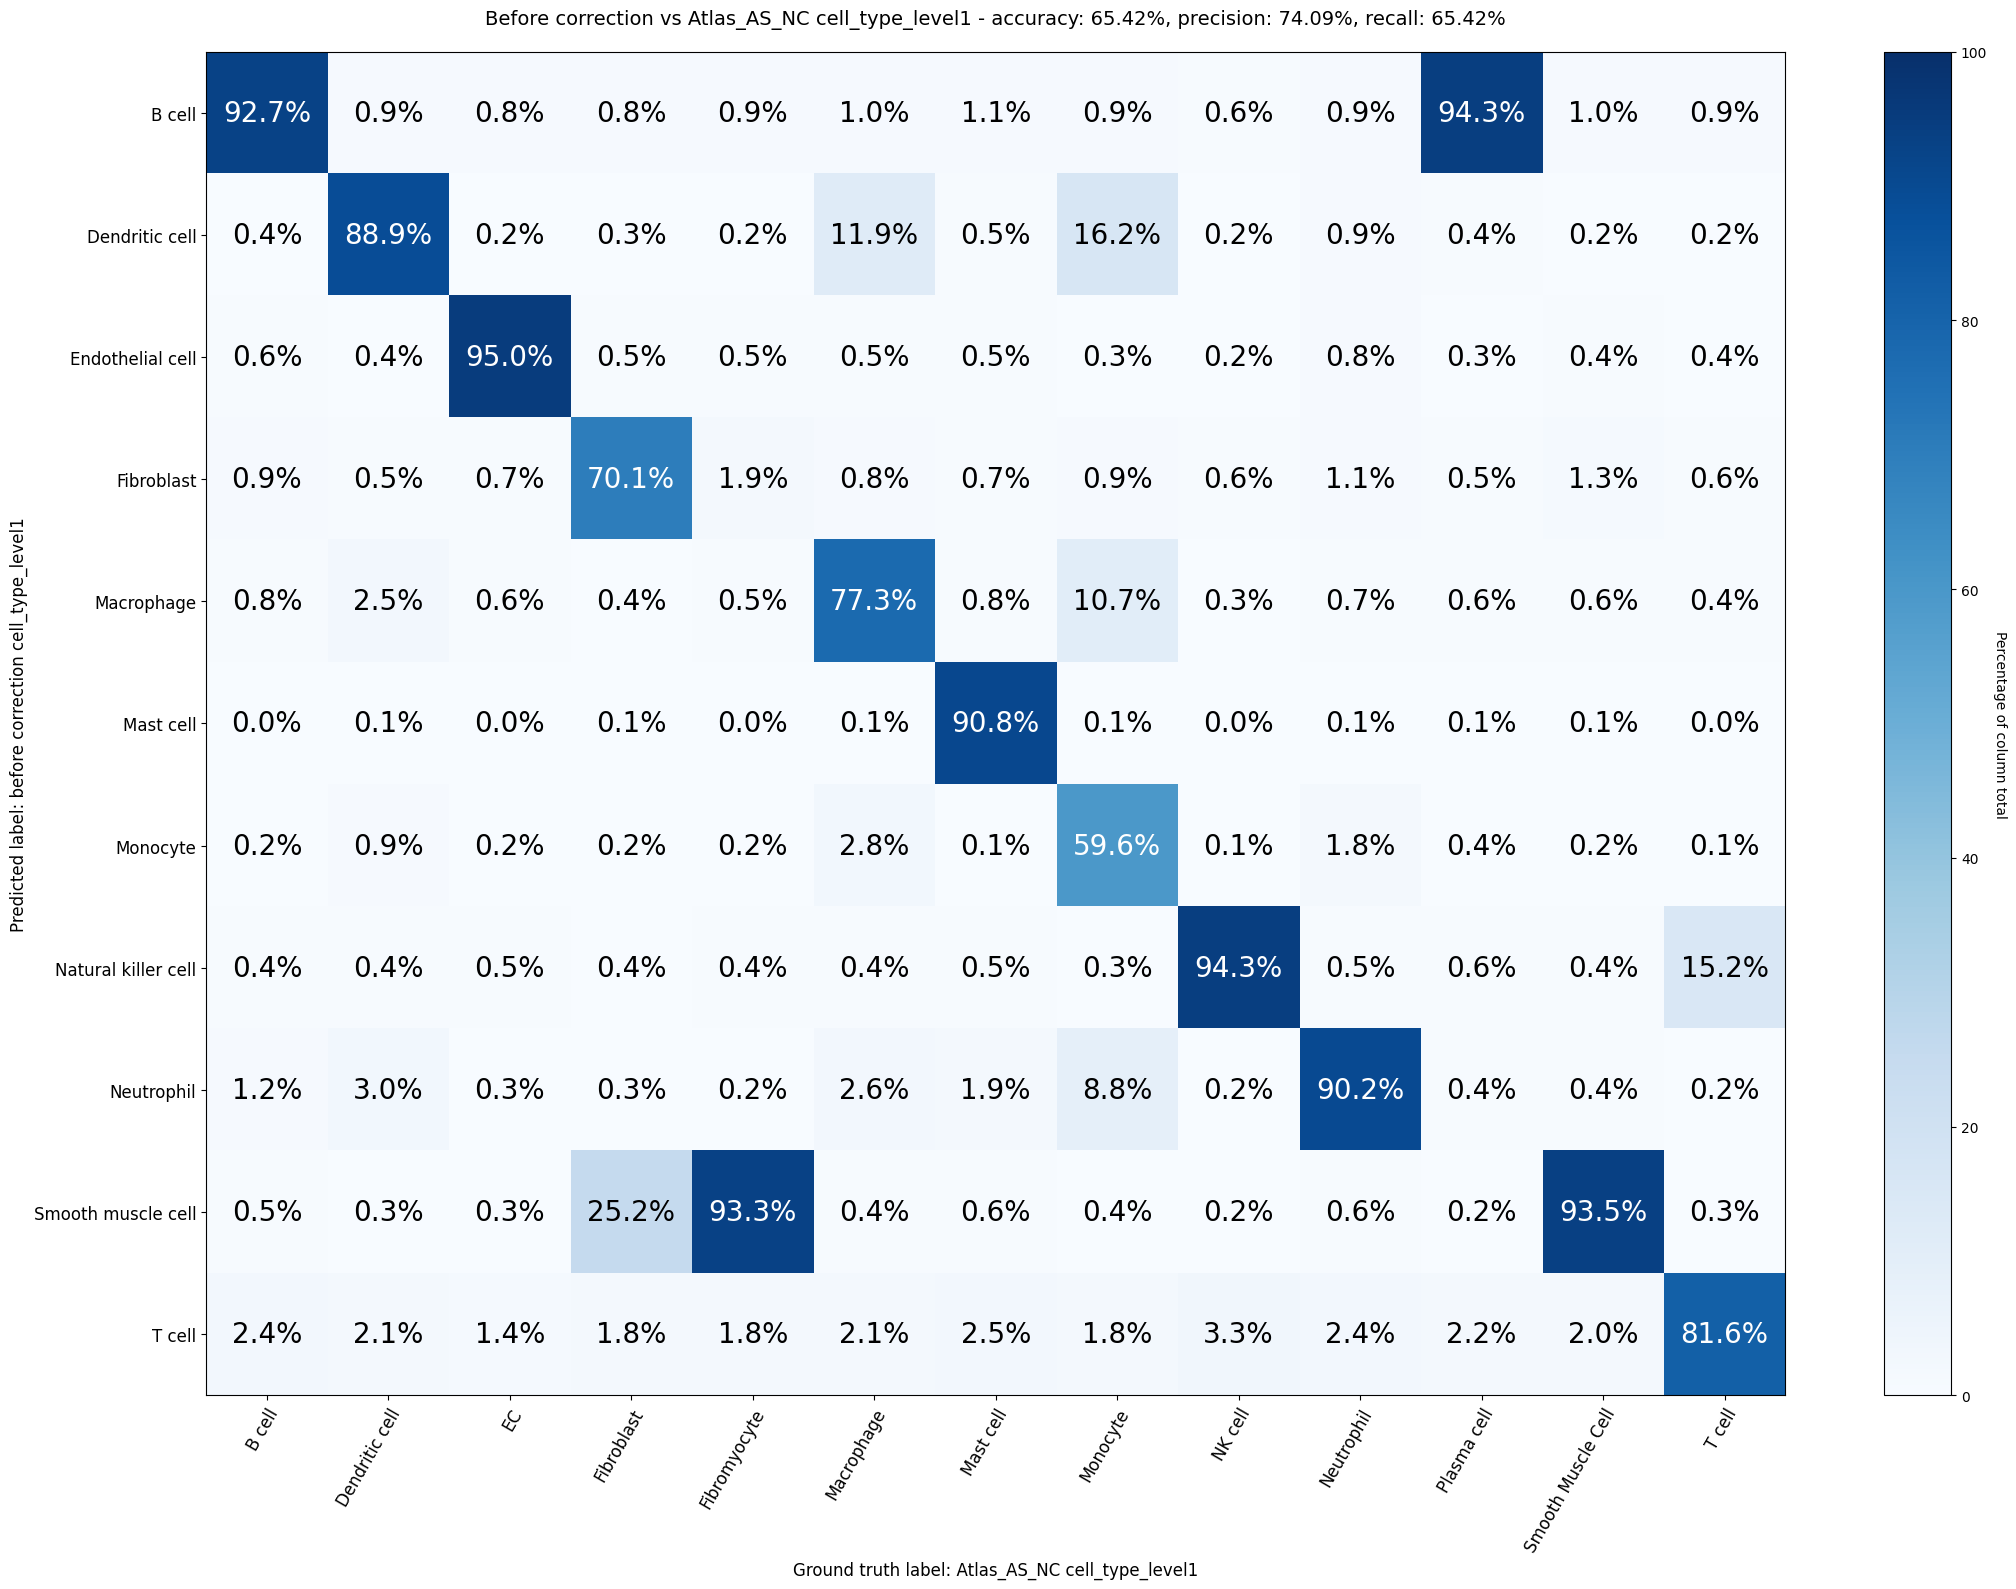


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.698687
1        Dendritic cell   0.489740
2      Endothelial cell   0.000000
3            Fibroblast   0.793011
4            Macrophage   0.923008
5             Mast cell   0.949030
6              Monocyte   0.822192
7   Natural killer cell   0.000000
8            Neutrophil   0.592249
9    Smooth muscle cell   0.000000
10               T cell   0.973452

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.926856
1       Dendritic cell  0.889253
2                   EC  0.000000
3           Fibroblast  0.701239
4         Fibromyocyte  0.000000
5           Macrophage  0.773457
6            Mast cell  0.908071
7             Monocyte  0.595854
8              NK cell  0.000000
9           Neutrophil  0.901912
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.815722


In [ ]:
###校正前
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


path_bef="/home/lixiangyu/zr/Annotate/ANNOTATE_new/7.5_correct/0511_rename_noIAISR/output_allhuman/work_0513_2/scPoli_concat_corrected_all.h5ad"
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)

## 与NC 专家数据集进行验证

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/anndata/_core/anndata.py:1897: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


当前 AnnData 中共有 548208 个细胞
去除指定细胞类型后共有 529042 个细胞
参考 AnnData 中共有 259116 个细胞
共同匹配到 190893 个细胞

Ground truth cell types from Atlas_AS_NC.h5ad:
['B cell', 'Dendritic cell', 'EC', 'Fibroblast', 'Fibromyocyte', 'Macrophage', 'Mast cell', 'Monocyte', 'NK cell', 'Neutrophil', 'Plasma cell', 'Smooth Muscle Cell', 'T cell']

Predicted cell types from current adata:
['B cell', 'Dendritic cell', 'Endothelial cell', 'Fibroblast', 'Macrophage', 'Mast cell', 'Monocyte', 'Natural killer cell', 'Neutrophil', 'Smooth muscle cell', 'T cell']

Accuracy: 0.6525
Weighted precision: 0.7411
Weighted recall: 0.6525

每列百分比加和:
[100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100. 100.]


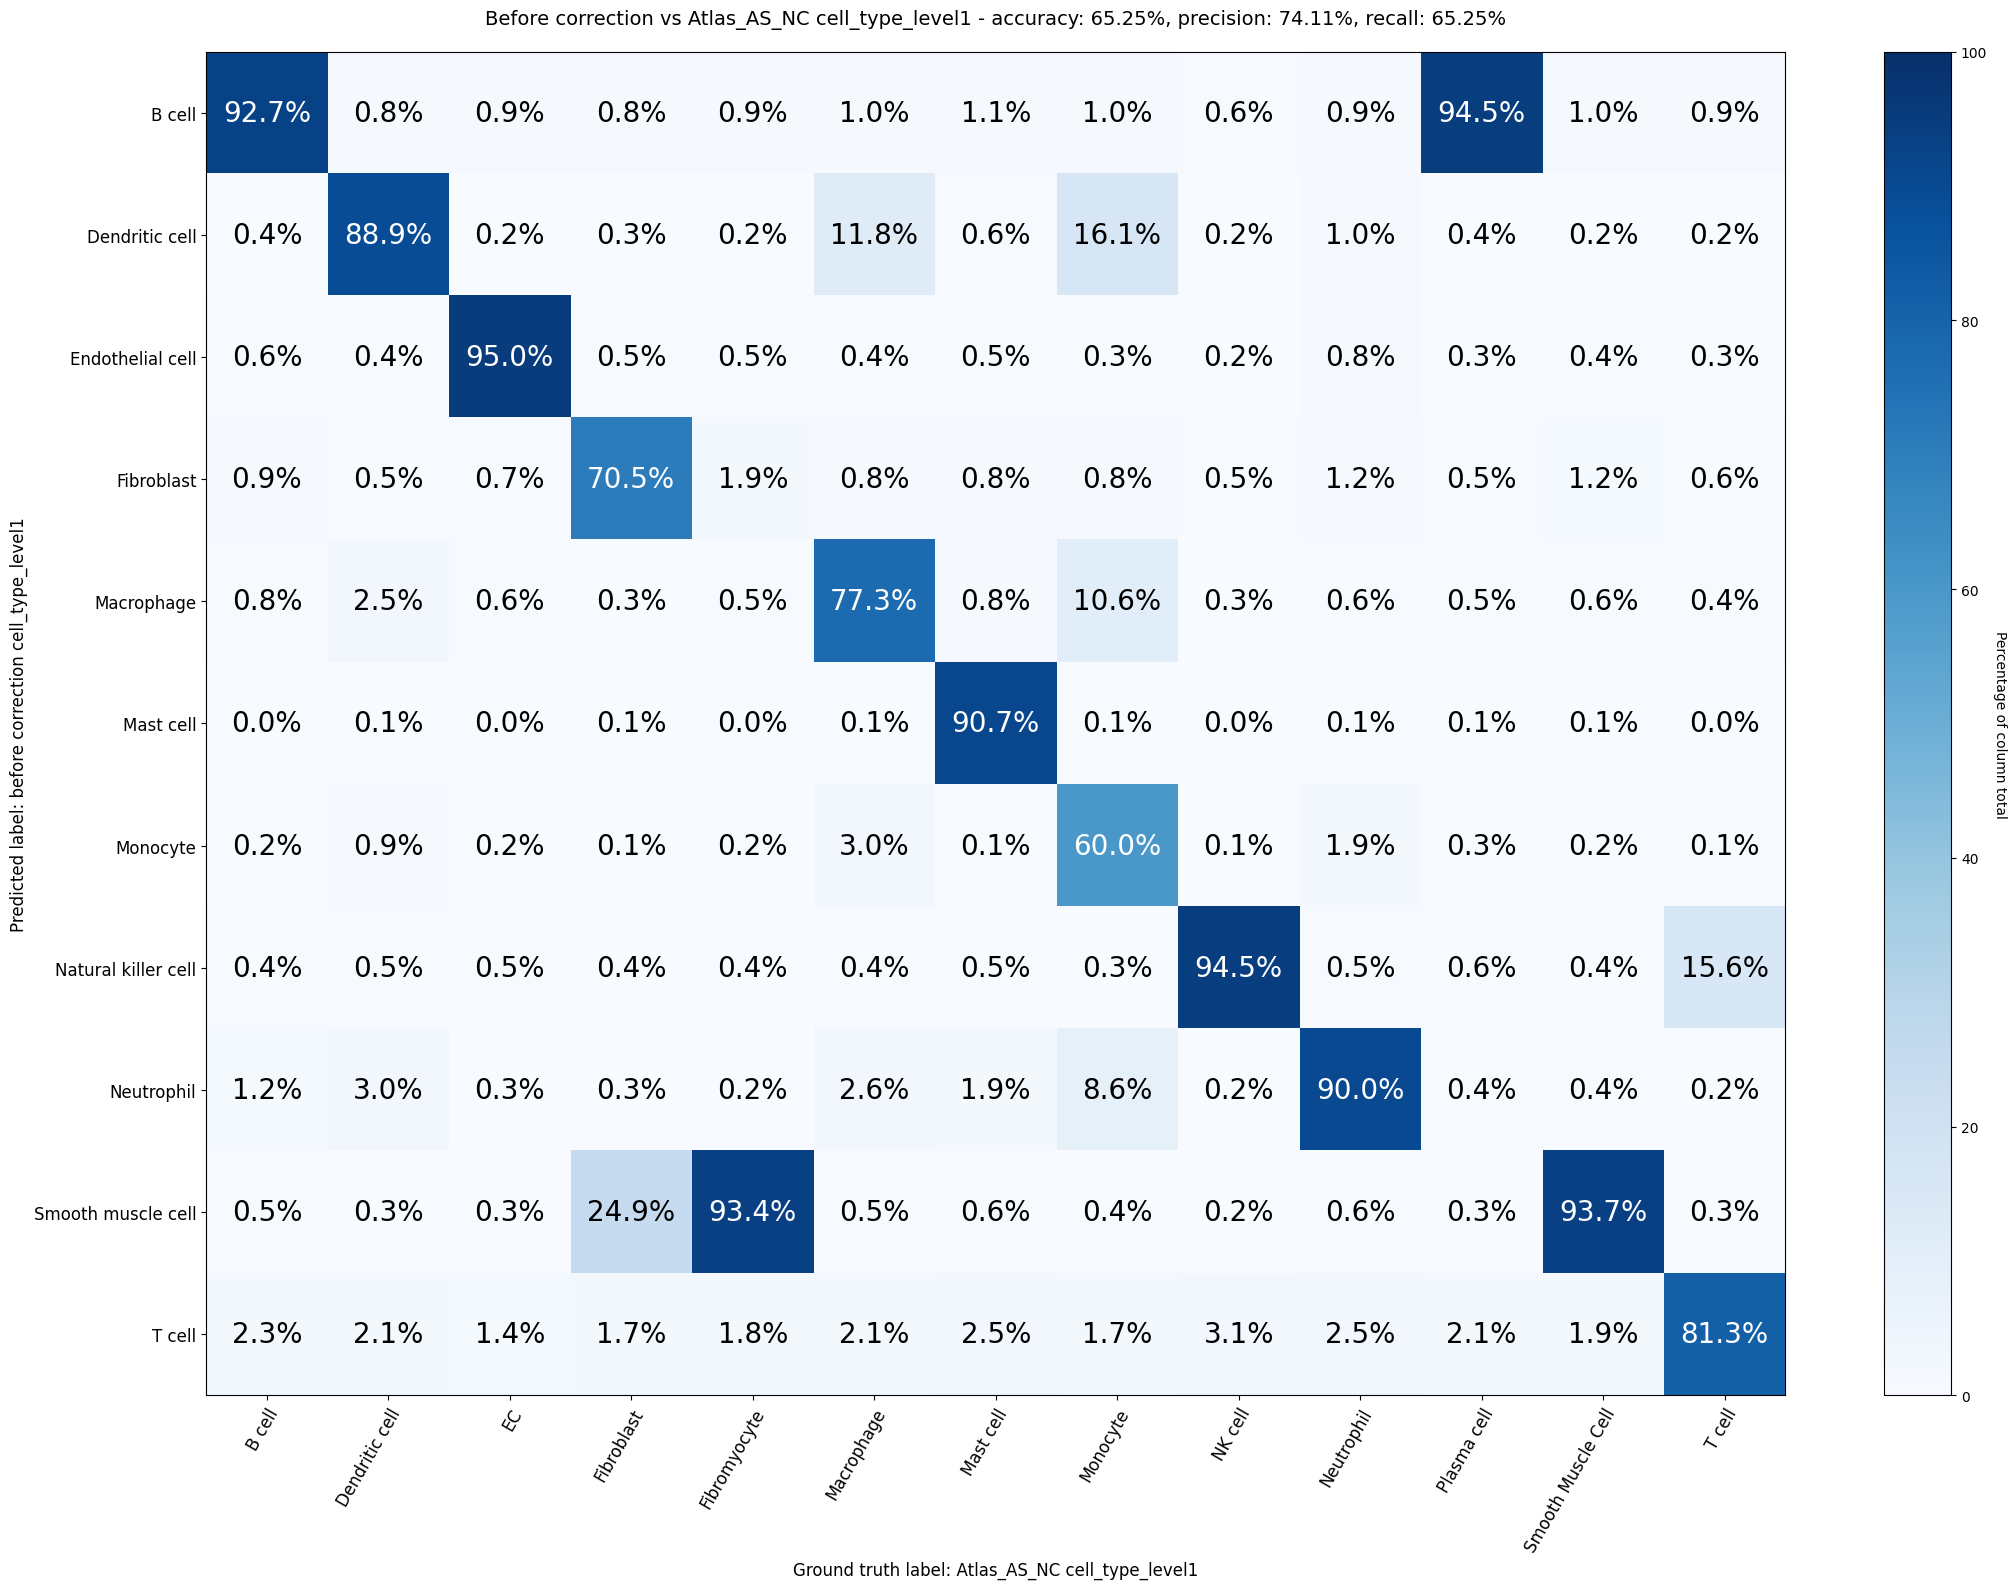


Per-predicted-cell-type precision:
              cell_type  precision
0                B cell   0.693848
1        Dendritic cell   0.494047
2      Endothelial cell   0.000000
3            Fibroblast   0.800030
4            Macrophage   0.922544
5             Mast cell   0.947652
6              Monocyte   0.818527
7   Natural killer cell   0.000000
8            Neutrophil   0.587604
9    Smooth muscle cell   0.000000
10               T cell   0.974329

Per-ground-truth-cell-type recall:
             cell_type    recall
0               B cell  0.927384
1       Dendritic cell  0.889357
2                   EC  0.000000
3           Fibroblast  0.705485
4         Fibromyocyte  0.000000
5           Macrophage  0.772868
6            Mast cell  0.906835
7             Monocyte  0.600417
8              NK cell  0.000000
9           Neutrophil  0.899635
10         Plasma cell  0.000000
11  Smooth Muscle Cell  0.000000
12              T cell  0.812570


In [22]:
#
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import accuracy_score,precision_score,recall_score
from matplotlib import colors


path_bef="../../7_mapping_new_data/0511_rename_noIAISR/output_human/Atlas_allhuman_with_measure_allgeneID-inner-counts-annot.h5ad"
adata_bef_correct=sc.read_h5ad(path_bef,backed="r")

remove_cell_types=["Pericyte","Basophil","Erythrocyte/Erythroid"]
adata.obs_names = adata.obs_names.astype(str)
adata_query = adata[adata.obs['atlas_key'] == 'query']
adata_query.obs_names_make_unique()
adata_ref.obs_names_make_unique()

n_obs_before=adata_query.n_obs
n_obs_ref=adata_ref.n_obs

obs_before=adata_query.obs[["cell_type_level1"]].copy()
obs_before.index=adata_query.obs_names.copy()
obs_ref=adata_ref.obs[["cell_type_level1"]].copy()
obs_ref.index=adata_ref.obs_names.copy()

adata_query.file.close()

obs_before=obs_before[~obs_before["cell_type_level1"].isin(remove_cell_types)]
common_indices=obs_before.index.intersection(obs_ref.index)

print(f"当前 AnnData 中共有 {n_obs_before} 个细胞")
print(f"去除指定细胞类型后共有 {obs_before.shape[0]} 个细胞")
print(f"参考 AnnData 中共有 {n_obs_ref} 个细胞")
print(f"共同匹配到 {len(common_indices)} 个细胞")

compare_df=pd.DataFrame({
    "pred":obs_before.loc[common_indices,"cell_type_level1"].astype(str),
    "gt":obs_ref.loc[common_indices,"cell_type_level1"].astype(str)
})

mapped_cell_types=compare_df["gt"].values
cell_types_pred=compare_df["pred"].values

gt_cell_types=sorted(compare_df["gt"].unique())
pred_cell_types=sorted(compare_df["pred"].unique())

print("\nGround truth cell types from Atlas_AS_NC.h5ad:")
print(gt_cell_types)
print("\nPredicted cell types from current adata:")
print(pred_cell_types)

conf_df=pd.crosstab(
    pd.Categorical(compare_df["pred"],categories=pred_cell_types),
    pd.Categorical(compare_df["gt"],categories=gt_cell_types),
    rownames=["Predicted label"],
    colnames=["Ground truth label"],
    dropna=False
)

conf_matrix=conf_df.to_numpy()
accuracy=accuracy_score(mapped_cell_types,cell_types_pred)

precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    labels=pred_cell_types,
    average=None,
    zero_division=0
)

recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    labels=gt_cell_types,
    average=None,
    zero_division=0
)

overall_precision=precision_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

overall_recall=recall_score(
    mapped_cell_types,
    cell_types_pred,
    average="weighted",
    zero_division=0
)

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted precision: {overall_precision:.4f}")
print(f"Weighted recall: {overall_recall:.4f}")

col_sums=conf_matrix.sum(axis=0,keepdims=True)
conf_matrix_percentages=np.divide(
    conf_matrix,
    col_sums,
    out=np.zeros_like(conf_matrix,dtype=float),
    where=col_sums!=0
)*100

print("\n每列百分比加和:")
print(conf_matrix_percentages.sum(axis=0))

fig,ax=plt.subplots(figsize=(22,16))
norm=colors.Normalize(vmin=0,vmax=100)

im=ax.imshow(
    conf_matrix_percentages,
    interpolation="nearest",
    cmap=plt.cm.Blues,
    norm=norm,
    aspect="auto"
)

cbar=ax.figure.colorbar(im,ax=ax)
cbar.ax.set_ylabel("Percentage of column total",rotation=-90,va="bottom")

ax.set(
    xticks=np.arange(len(gt_cell_types)),
    yticks=np.arange(len(pred_cell_types)),
    xticklabels=gt_cell_types,
    yticklabels=pred_cell_types,
    title=(
        f"Before correction vs Atlas_AS_NC cell_type_level1 - "
        f"accuracy: {accuracy:.2%}, "
        f"precision: {overall_precision:.2%}, "
        f"recall: {overall_recall:.2%}"
    ),
    ylabel="Predicted label: before correction cell_type_level1",
    xlabel="Ground truth label: Atlas_AS_NC cell_type_level1"
)

plt.setp(ax.get_xticklabels(),rotation=60,ha="right",rotation_mode="anchor",fontsize=12)
plt.setp(ax.get_yticklabels(),fontsize=12)

for i in range(conf_matrix.shape[0]):
    for j in range(conf_matrix.shape[1]):
        if conf_matrix[i,j]>0:
            ax.text(
                j,
                i,
                # str(conf_matrix[i,j]),
                f"{conf_matrix_percentages[i,j]:.1f}%",
                ha="center",
                va="center",
                fontsize=20,
                color="white" if conf_matrix_percentages[i,j]>50 else "black"
            )

ax.set_title(ax.get_title(),fontsize=14,pad=20)
ax.set_xlabel("Ground truth label: Atlas_AS_NC cell_type_level1",fontsize=12)
ax.set_ylabel("Predicted label: before correction cell_type_level1",fontsize=12)

fig.tight_layout()

# plt.savefig(os.path.join(outdir, "verify_before_correction.png"),dpi=200)
plt.show()

precision_df=pd.DataFrame({"cell_type":pred_cell_types,"precision":precision})
recall_df=pd.DataFrame({"cell_type":gt_cell_types,"recall":recall})

print("\nPer-predicted-cell-type precision:")
print(precision_df)

print("\nPer-ground-truth-cell-type recall:")
print(recall_df)